In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

from LSSVMClassification import LSSVMClassification

In [4]:
df = pd.read_excel("Chemical_Fingerprint_Singles_Normalized_Classes.xlsx")

X = df.drop(columns=["BandGap", "Class"])
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

model = LSSVMClassification(
    gamma=1,
    kernel="rbf",
    sigma=1
)
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(model, X, y, cv=cv)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Fold accuracies:", scores)
print("Mean accuracy:", scores.mean())

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Fold accuracies: [0.655902   0.65144766 0.68262806 0.65144766 0.6403118 ]
Mean accuracy: 0.6563474387527839
Accuracy: 0.6492204899777283

Confusion Matrix
[[170 190]
 [125 413]]

Classification Report
              precision    recall  f1-score   support

          -1       0.58      0.47      0.52       360
           1       0.68      0.77      0.72       538

    accuracy                           0.65       898
   macro avg       0.63      0.62      0.62       898
weighted avg       0.64      0.65      0.64       898



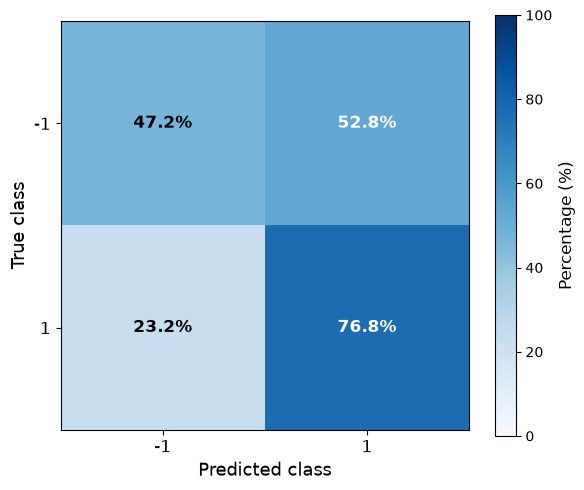

In [10]:
# heatmap

cm = confusion_matrix(y_test, y_pred)
cm_percent = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, ax = plt.subplots(figsize=(6,5))

im = ax.imshow(cm_percent, cmap="Blues", vmin=0, vmax=100)

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Percentage (%)", fontsize=12)


# Axis labels
ax.set_xlabel("Predicted class", fontsize=13)
ax.set_ylabel("True class", fontsize=13)

# Tick labels
classes = ["-1", "1"]
ax.set_xticks(np.arange(len(classes)))
ax.set_yticks(np.arange(len(classes)))
ax.set_xticklabels(classes, fontsize=12)
ax.set_yticklabels(classes, fontsize=12)

# Add percentage values inside the cells
for i in range(cm_percent.shape[0]):
    for j in range(cm_percent.shape[1]):
        ax.text(
            j,
            i,
            f"{cm_percent[i, j]:.1f}%",
            ha="center",
            va="center",
            color="white" if cm_percent[i, j] > 50 else "black",
            fontsize=12,
            fontweight="bold"
        )

plt.tight_layout()
plt.show()

#biased decision boundary toward predicting class 1, imbalance? overlapping feature distributions?
#LS SVM sigma and gamma change?


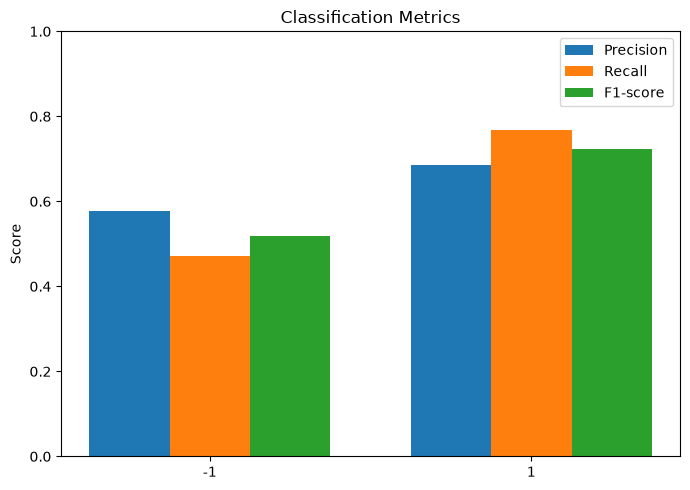

In [12]:
precision, recall, f1, _ = precision_recall_fscore_support(
    y_test,
    y_pred,
    labels=[-1,1]
)

metrics = np.array([precision, recall, f1])

labels = ["Precision","Recall","F1-score"]
classes = ["-1","1"]

x = np.arange(len(classes))
width = 0.25

plt.figure(figsize=(7,5))

for i in range(3):
    plt.bar(x + i*width,
            metrics[i],
            width,
            label=labels[i])

plt.xticks(x + width, classes)
plt.ylim(0,1)
plt.ylabel("Score")
plt.title("Classification Metrics")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# vorige aanpak doen: grid search voor hyperparameters en standardscaler before training

# Read dataset
df = pd.read_excel("Chemical_Fingerprint_Singles_Normalized_Classes.xlsx")

# Features and labels
X = df.drop(columns=["BandGap", "Class"])
y = df["Class"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Standardize
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# LS-SVM model
model = LSSVMClassification(kernel="rbf")

# Parameter grid
param_grid = {
    "gamma": [0.01, 0.1, 1, 10, 100],
    "sigma": [0.01, 0.1, 0.5, 1, 2, 5, 10]
}

grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

print("Best parameters:")
print(grid.best_params_)

print("\nBest CV accuracy:")
print(grid.best_score_)

In [ ]:
# evaluate the best model 
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

print("Test accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification report")
print(classification_report(y_test, y_pred))

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame(grid.cv_results_)

heatmap = results.pivot(
    index="param_sigma",
    columns="param_gamma",
    values="mean_test_score"
)

plt.figure(figsize=(8,6))

plt.imshow(
    heatmap,
    origin="lower",
    aspect="auto",
    cmap="viridis"
)

plt.colorbar(label="Cross-validation accuracy")

plt.xticks(
    range(len(heatmap.columns)),
    heatmap.columns
)

plt.yticks(
    range(len(heatmap.index)),
    heatmap.index
)

plt.xlabel("Gamma")
plt.ylabel("Sigma")
plt.title("LS-SVM Hyperparameter Grid Search")

for i in range(heatmap.shape[0]):
    for j in range(heatmap.shape[1]):
        plt.text(
            j,
            i,
            f"{heatmap.iloc[i,j]:.3f}",
            ha="center",
            va="center",
            color="white",
            fontsize=8
        )

plt.tight_layout()
plt.show()